# Source audit and coverage
Executed review notebook generated after the data pipeline was implemented. Re-runs the real source audit, not manually entered counts.

In [1]:
from pathlib import Path
import sys, json
import pandas as pd
import numpy as np
ROOT = Path.cwd()
if not (ROOT / 'backend').exists(): ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from backend.database import make_engine
import matplotlib.pyplot as plt


In [2]:
from scripts.audit_data import audit
report = audit(ROOT/'dataset')
pd.DataFrame([{'table':n,'rows':t['rows'],'years':str(t['year_range']),'missing_cells':sum(c['missing'] for c in t['columns'].values())} for n,t in report['tables'].items()])

,table,rows,years,missing_cells
0,circuits,77,None,0
1,constructors,212,None,0
2,drivers,861,None,1559
3,races,1125,"[1950, 2024]",11349
4,seasons,75,"[1950, 2024]",0
5,status,139,None,0
6,results,26759,"[1950, 2024]",122887
7,qualifying,10494,"[1994, 2024]",11668
8,constructor_results,12625,"[1958, 2024]",12608
9,constructor_standings,13391,"[1958, 2024]",0


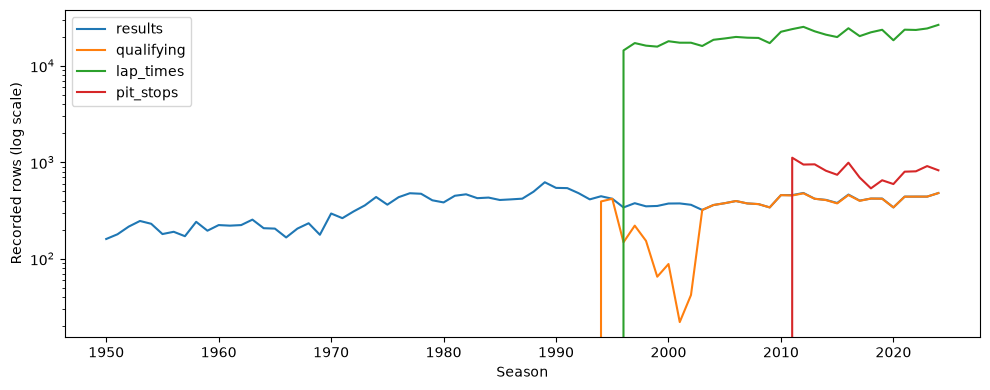

In [3]:
coverage = pd.DataFrame({n:t['rows_by_year'] for n,t in report['tables'].items() if t['rows_by_year']}).fillna(0)
ax=coverage[['results','qualifying','lap_times','pit_stops']].plot(figsize=(10,4),logy=True)
ax.set_ylabel('Recorded rows (log scale)'); ax.set_xlabel('Season'); plt.tight_layout(); plt.show()

Coverage starts do not imply complete recording. Weather and tyres are absent. The storage grain preserves historical shared-drive result records. See the audited limitations and sprint-era constructor-points finding in the repository.